In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

(500, 5)


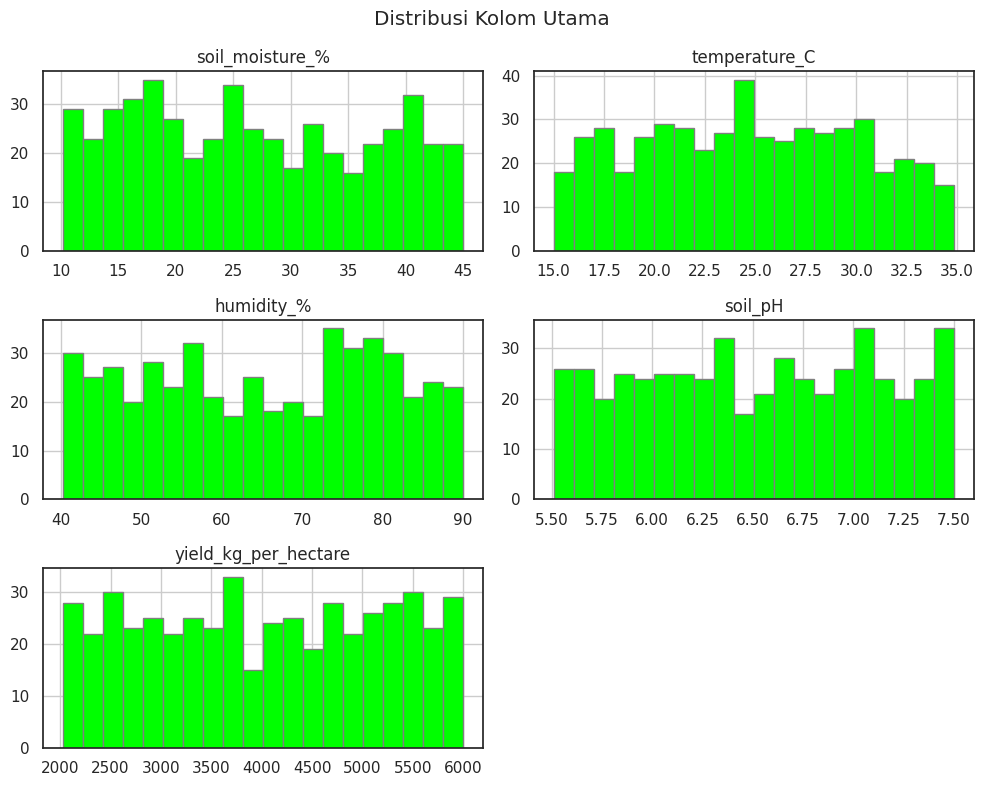

In [ ]:
# membaca Data csv
df = pd.read_csv('Smart_Farming_Crop_Yield_2024.csv')

# kolom Utama No 1
main_cols = ['soil_moisture_%', 'temperature_C', 'humidity_%', 'soil_pH', 'yield_kg_per_hectare']
df_main = df[main_cols].copy()

# tampilan kolom & baris
print(df_main.shape)
df_main.head()

# ringkasan statistik
df_main.describe()

# cek nilai null
df_main.isnull().sum()

# diagram
df_main.hist(bins=20, figsize=(10, 8), color='lime', edgecolor='grey')
plt.suptitle('Distribusi Kolom Utama')
plt.tight_layout()
plt.show()


In [ ]:
# handle missing values
df_main.fillna(df_main.median(), inplace=True)

# outliers
for coloums in main_cols:
    Q1 = df[coloums].quantile(0.25)
    Q3 = df[coloums].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[((df[coloums] <= Q1 - 1.5 * IQR)) & (df[coloums] >= (Q3 + 1.5 * IQR))]

# format datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['month']     = df['timestamp'].dt.to_period('M')

print("data setelah cleaning:", df_main.shape)
df_main.describe()

data setelah cleaning: (500, 5)


,soil_moisture_%,temperature_C,humidity_%,soil_pH,yield_kg_per_hectare
count,500.000000,500.000000,500.000000,500.000000,500.00000
mean,26.750140,24.675740,65.194460,6.523980,4032.92694
std,10.150053,5.348899,14.642849,0.585558,1174.43304
min,10.160000,15.000000,40.230000,5.510000,2023.56000
25%,17.890000,20.295000,51.865000,6.030000,2994.82000
50%,25.855000,24.655000,65.685000,6.530000,4071.69000
75%,36.022500,29.090000,77.995000,7.040000,5062.11000
max,44.980000,34.840000,90.000000,7.500000,5998.29000


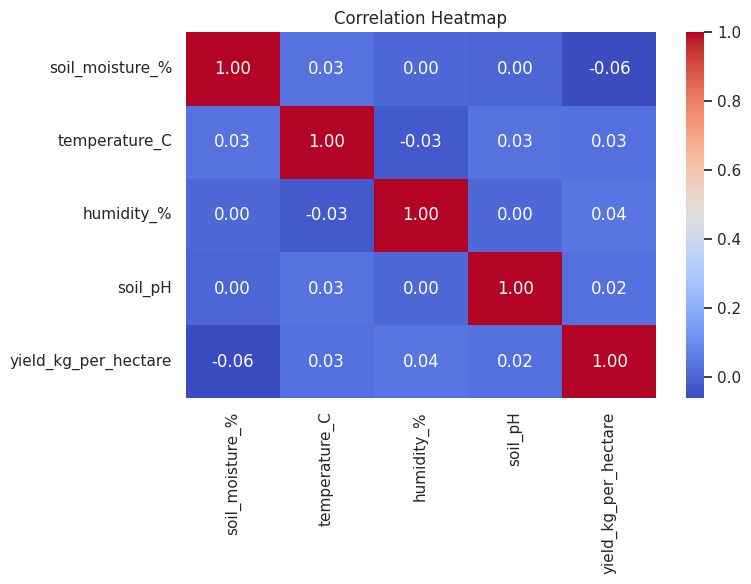

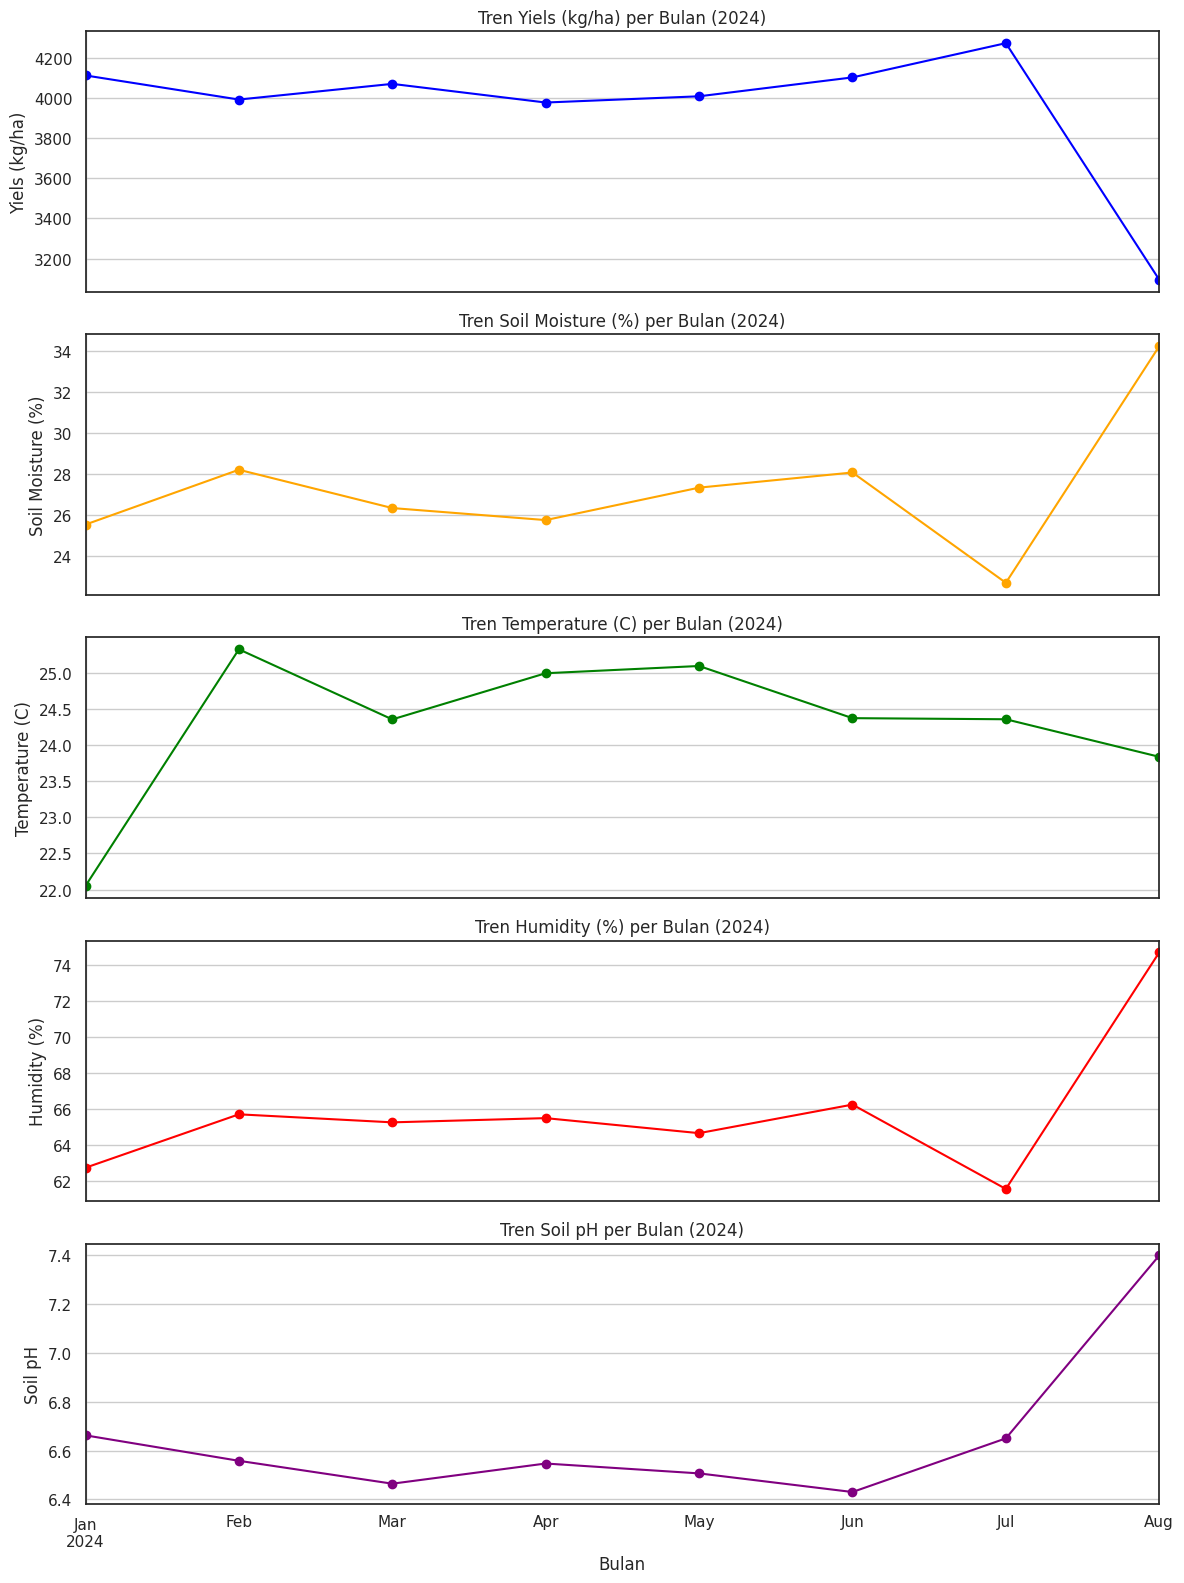

In [ ]:
from matplotlib import axes
# correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_main.corr(),annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation.heatmap.png')
plt.show()

# time series trend
df_ts = df[['timestamp', 'yield_kg_per_hectare', 'soil_moisture_%', 'temperature_C', 'humidity_%', 'soil_pH']].copy()
df_ts['month'] = df_ts['timestamp'].dt.to_period('M')
monthly = df_ts.groupby('month')[['yield_kg_per_hectare', 'soil_moisture_%', 'temperature_C', 'humidity_%', 'soil_pH']].mean()

# plot semua tren
fig, axes = plt.subplots(5, 1, figsize=(12, 16), sharex=True)
cols_plot = {
    'yield_kg_per_hectare': ('blue', 'Yiels (kg/ha)'),
    'soil_moisture_%'     : ('orange', 'Soil Moisture (%)'),
    'temperature_C'       : ('green', 'Temperature (C)'),
    'humidity_%'          : ('red', 'Humidity (%)'),
    'soil_pH'             : ('purple', 'Soil pH'),
}

for ax, (col, (color, label)) in zip(axes, cols_plot.items()):
    monthly[col].plot(ax=ax, marker='o', color=color)
    ax.set_title(f'Tren {label} per Bulan (2024)')
    ax.set_ylabel(label)
    ax.grid(True)

plt.xlabel('Bulan')
plt.tight_layout()
plt.savefig('time_series_trend.png')
plt.show()

In [ ]:
# kolom utama yang sudah di cleaning + timestamp
df_clean = df_main.copy()
df_clean['timestamp'] = df.loc[df_main.index, 'timestamp']

# simpan
df_clean.to_csv('cleaned_data.csv', index=False)
print("File berhasil disimpan!")

from google.colab import files
files.download('cleaned_data.csv')

File berhasil disimpan!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from datetime import datetime, timedelta

df = pd.read_csv('Smart_Farming_Crop_Yield_2024.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

total = len(df)
total_cells = df.size

# accuracy
missing = df.isnull().sum().sum()
accuracy = 1 - (missing / total_cells)

# completeness
non_null = df.notnull().sum().sum()
completeness = non_null / total_cells

# timeliness
cutoff = df['timestamp'].max() - timedelta(days=30)
timeliness = len(df[df['timestamp'] >= cutoff]) / total

print("=" * 27)
print(" DATA QUALITY SCORE REPORT")
print("=" * 27)
print(f"Total Rows: {total}")
print(f"Missing Values: {missing}")
print(f"Accuracy: {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Completeness: {completeness:.4f} ({completeness * 100:.2f}%)")
print(f"Timeliness: {timeliness:.4f} ({timeliness * 100:.2f}%)")
print("-" * 27)
overall = (accuracy + completeness + timeliness) / 3
print(f"Overall DQ Score: {overall:.4f} ({overall * 100:.2f}%)")
print("=" * 27)

 DATA QUALITY SCORE REPORT
Total Rows: 500
Missing Values: 280
Accuracy: 0.9745 (97.45%)
Completeness: 0.9745 (97.45%)
Timeliness: 0.0140 (1.40%)
---------------------------
Overall DQ Score: 0.6544 (65.44%)
